In [5]:
# ==============================
# 🌍 PyGMT Notebook Setup Cell
# ==============================

import pygmt
import os

# 1. Confirm PyGMT and GMT versions
print("PyGMT version:", pygmt.__version__)
pygmt.show_versions()

# 2. (Optional) Set default figure display mode for Jupyter
pygmt.config(FORMAT_GEO_MAP="ddd.xx")  # Clean geographic labels
pygmt.set_display(method="notebook")   # Inline plotting in Jupyter

# 3. Optional: set your working directory
# os.chdir("/path/to/your/project")

print("PyGMT environment initialized ✅")


PyGMT version: v0.15.0
PyGMT information:
  version: v0.15.0
System information:
  python: 3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:18:52) [Clang 18.1.8 ]
  executable: /Users/solarsmith/micromamba/envs/pygmt-jupyter/bin/python
  machine: macOS-15.6-arm64-arm-64bit
Dependency information:
  numpy: 2.2.5
  pandas: 2.2.3
  xarray: 2025.4.0
  netCDF4: 1.7.2
  packaging: 25.0
  contextily: None
  geopandas: None
  IPython: 9.2.0
  pyarrow: None
  rioxarray: None
  gdal: None
  ghostscript: 10.04.0
GMT library information:
  version: 6.5.0
  padding: 2
  share dir: /Users/solarsmith/micromamba/envs/pygmt-jupyter/share/gmt
  plugin dir: /Users/solarsmith/micromamba/envs/pygmt-jupyter/lib/gmt/plugins
  library path: /Users/solarsmith/micromamba/envs/pygmt-jupyter/lib/libgmt.dylib
  cores: 8
  grid layout: rows
  image layout: 
  binary version: 6.5.0
PyGMT environment initialized ✅


This is a markdown Cell


In [6]:
data = pygmt.datasets.load_sample_data(name="japan_quakes")
data.head()

,year,month,day,latitude,longitude,depth_km,magnitude
0,1987,1,4,49.77,149.29,489,4.1
1,1987,1,9,39.90,141.68,67,6.8
2,1987,1,9,39.82,141.64,84,4.0
3,1987,1,14,42.56,142.85,102,6.5
4,1987,1,16,42.79,145.10,54,5.1


In [7]:
region = [
    data.longitude.min() - 1,
    data.longitude.max() + 1,
    data.latitude.min() - 1,
    data.latitude.max() + 1,
]
region

[np.float64(131.29), np.float64(150.89), np.float64(34.02), np.float64(50.77)]

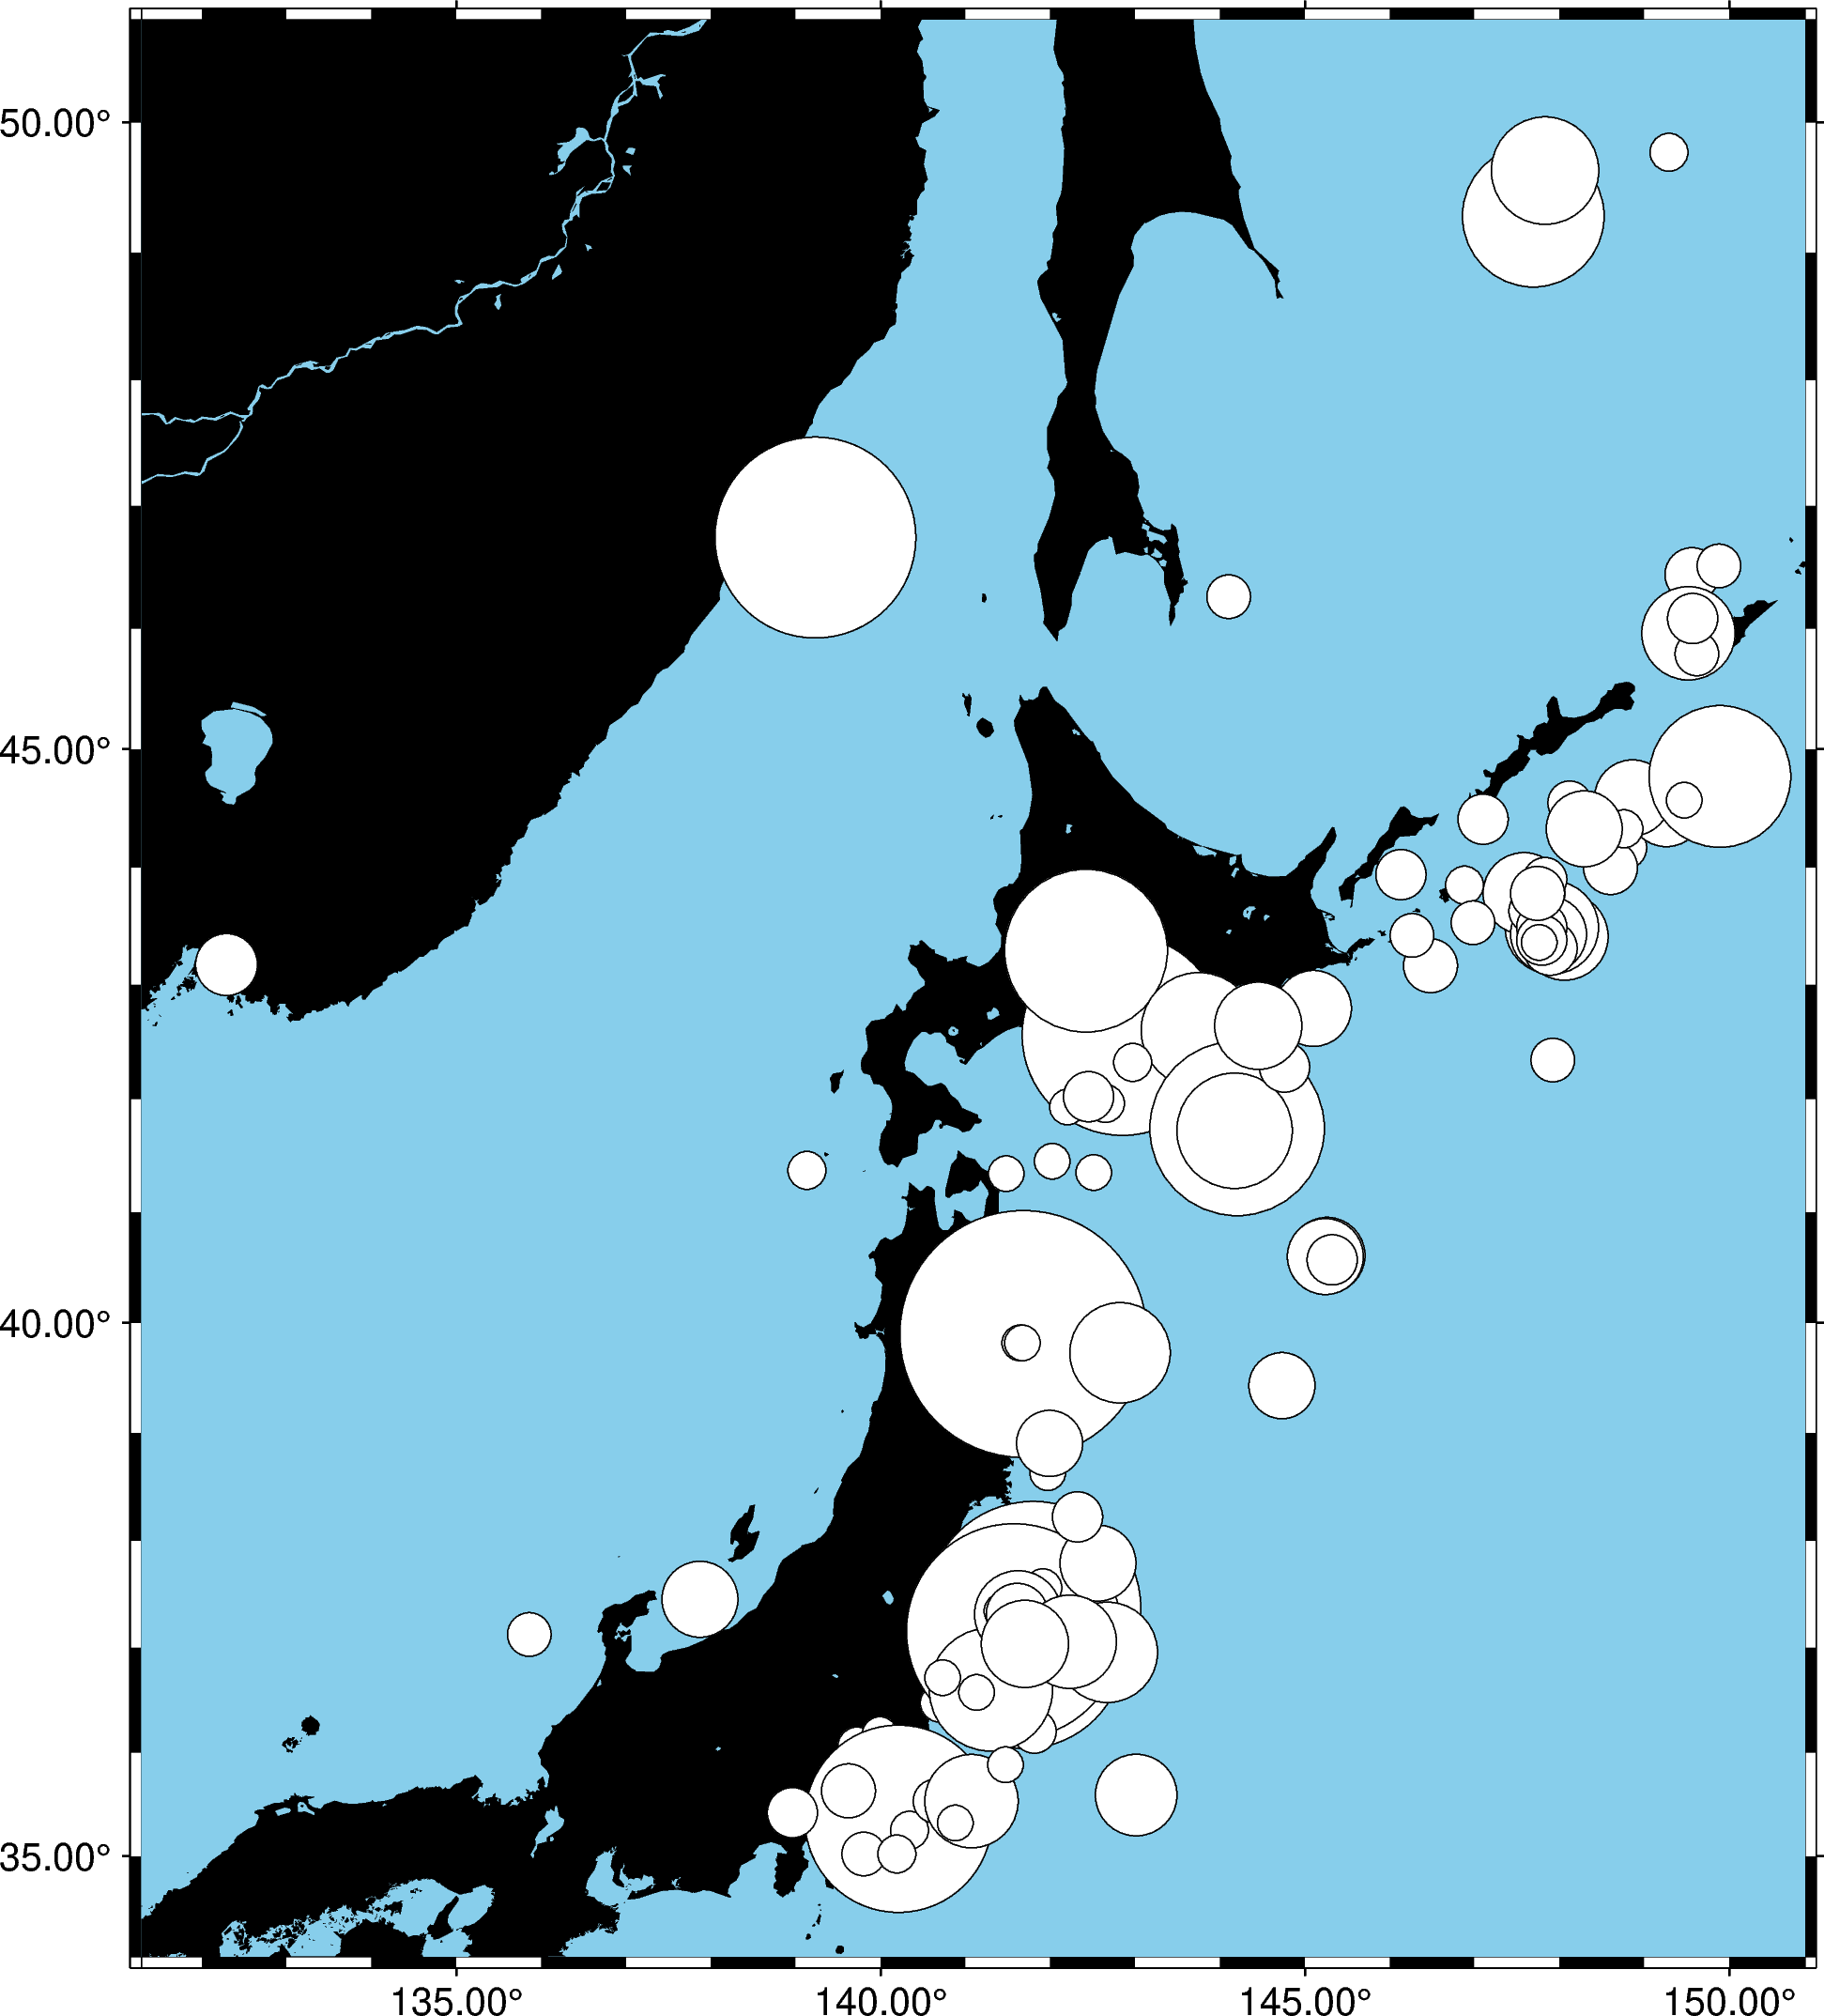

In [12]:
quakeFig = pygmt.Figure()
quakeFig.basemap(region=region, projection="M15c", frame=True)
quakeFig.coast(land="black", water="skyblue")
pygmt.makecpt(cmap="viridis", series=[data.depth_km.min(), data.depth_km.max()])
quakeFig.plot(
    x=data.longitude, 
    y=data.latitude, 
    size=0.02 * (2**data.magnitude),
    style="cc", 
    fill=data.depth_km,
    cmap=True,
    pen="black",
)
quakeFig.colorbar(frame="xaf+lDepth (km)")
quakeFig.show()